<a href="https://colab.research.google.com/github/Kavishka2401/CustomerChurnPredictionSystem/blob/master/2_Preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Data Pre-Processing for Neural Networks**

In [1]:
# Mount the google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Import libraries
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Provide path
data=pd.read_csv('/content/drive/MyDrive/Customer_Churn_Data.csv')

In [4]:
# Make a copy of the original dataset to work with
data_copy = data.copy()
df_nn = data_copy

In [5]:
import pandas as pd

# Show all columns
pd.set_option('display.max_columns', None)

# Show all rows if needed
pd.set_option('display.max_rows', None)

# Optional: prevent truncation of long strings in cells
pd.set_option('display.max_colwidth', None)

# Now when you do
df_nn.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [21]:
# Create a numeric column for TotalCharges
df_nn['TotalCharges_numeric'] = pd.to_numeric(df_nn['TotalCharges'], errors='coerce')

# Check for missing values after conversion
missing_total_charges = df_nn['TotalCharges_numeric'].isnull().sum()
print(f"Missing values in TotalCharges_numeric: {missing_total_charges}")

Missing values in TotalCharges_numeric: 11


In [22]:
# Display rows with missing TotalCharges_numeric
missing_rows = df_nn[df_nn['TotalCharges_numeric'].isnull()]
missing_rows

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TotalCharges_numeric
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No,NaN
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No,NaN
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,No,Yes,Yes,Two year,No,Mailed check,80.85,,No,NaN
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No,NaN
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No,NaN
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No,NaN
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No,NaN
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No,NaN
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No,NaN
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,No,Two year,No,Mailed check,73.35,,No,NaN


In [23]:
# Compute median of TotalCharges_numeric
median_total_charges = df_nn['TotalCharges_numeric'].median()

# Impute missing values with median
df_nn['TotalCharges_numeric'] = df_nn['TotalCharges_numeric'].fillna(median_total_charges)

In [24]:
# Check if imputation has worked
check_missing_rows = df_nn[df_nn['TotalCharges_numeric'].isnull()]
check_missing_rows

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TotalCharges_numeric


In [25]:
# IQR method to detect outliers
num_features = ['TotalCharges_numeric', 'MonthlyCharges', 'tenure']

for col in num_features:
    Q1 = df_nn[col].quantile(0.25)
    Q3 = df_nn[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df_nn[(df_nn[col] < lower_bound) | (df_nn[col] > upper_bound)]
    print(f"{col}: {len(outliers)} outliers")

TotalCharges_numeric: 0 outliers
MonthlyCharges: 0 outliers
tenure: 0 outliers


In [26]:
# Checking if skew handling should be done to the numerical columns
df_nn[['TotalCharges_numeric', 'MonthlyCharges', 'tenure']].skew()

,0
TotalCharges_numeric,0.963789
MonthlyCharges,-0.220524
tenure,0.239540


In [27]:
# Log transform TotalCharges_numeric (Skew handling)
df_nn['TotalCharges_log'] = np.log1p(df_nn['TotalCharges_numeric'])

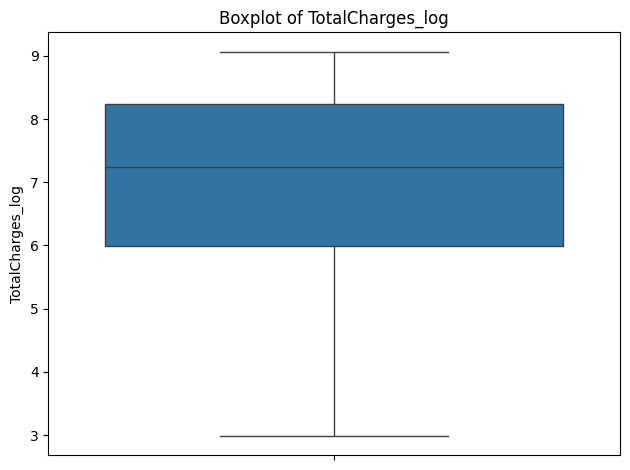

In [28]:
sns.boxplot(df_nn['TotalCharges_log'])
plt.title(f'Boxplot of {'TotalCharges_log'}')
plt.tight_layout()
plt.show()

In [29]:
from sklearn.preprocessing import MinMaxScaler

# List of numerical features to scale
num_features = ['TotalCharges_log', 'MonthlyCharges', 'tenure']

# Initialize MinMaxScaler
scaler = MinMaxScaler()

# Fit the scaler on the numerical features and transform
df_nn[num_features] = scaler.fit_transform(df_nn[num_features])

# Check the result
print(df_nn[num_features].describe())

       TotalCharges_log  MonthlyCharges       tenure
count       7043.000000     7043.000000  7043.000000
mean           0.650613        0.462803     0.449599
std            0.254000        0.299403     0.341104
min            0.000000        0.000000     0.000000
25%            0.495386        0.171642     0.125000
50%            0.699806        0.518408     0.402778
75%            0.863578        0.712438     0.763889
max            1.000000        1.000000     1.000000


In [30]:
# List of categorical features
cat_features = ['gender', 'SeniorCitizen', 'Partner', 'Dependents',
                'PhoneService', 'MultipleLines', 'InternetService',
                'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                'TechSupport', 'StreamingTV', 'StreamingMovies',
                'Contract', 'PaperlessBilling', 'PaymentMethod']

# One-hot encoding
df_nn_encoded = pd.get_dummies(df_nn, columns=cat_features, drop_first=True)

# Convert all boolean columns (True/False) to 0/1
bool_cols = df_nn_encoded.select_dtypes(include='bool').columns
df_nn_encoded[bool_cols] = df_nn_encoded[bool_cols].astype(int)

# Encode target variable Churn: No -> 0, Yes -> 1
df_nn_encoded['Churn'] = df_nn_encoded['Churn'].map({'No': 0, 'Yes': 1})

# Check the shape after encoding
print(df_nn_encoded.shape)

# Check first few rows
df_nn_encoded.head()

(7043, 34)


,customerID,tenure,MonthlyCharges,TotalCharges,Churn,TotalCharges_numeric,TotalCharges_log,gender_Male,SeniorCitizen_1,Partner_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,7590-VHVEG,0.013889,0.115423,29.85,0,29.85,0.072892,0,0,1,...,0,0,0,0,0,0,1,0,1,0
1,5575-GNVDE,0.472222,0.385075,1889.5,0,1889.50,0.749358,1,0,0,...,0,0,0,0,1,0,0,0,0,1
2,3668-QPYBK,0.027778,0.354229,108.15,1,108.15,0.280590,1,0,0,...,0,0,0,0,0,0,1,0,0,1
3,7795-CFOCW,0.625000,0.239303,1840.75,0,1840.75,0.745063,1,0,0,...,0,0,0,0,1,0,0,0,0,0
4,9237-HQITU,0.027778,0.521891,151.65,1,151.65,0.335724,0,0,0,...,0,0,0,0,0,0,1,0,1,0


In [31]:
df_nn_encoded.to_csv("/content/drive/MyDrive/processed_data_NN.csv", index=False)
print("Saved successfully!")

Saved successfully!
